In [2]:
#import libraries#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [20]:
#load dataset#
import pandas as pd

column_names = ['target', 'id', 'date', 'flag', 'user', 'text']

df = pd.read_csv(
    '/content/sample_data/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    names=column_names
)

In [21]:
df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [22]:
#understand the dataset#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [23]:
df.columns

Index(['target', 'id', 'date', 'flag', 'user', 'text'], dtype='object')

In [24]:
df.shape

(1600000, 6)

In [25]:
df.describe()

,target,id
count,1.600000e+06,1.600000e+06
mean,2.000000e+00,1.998818e+09
std,2.000001e+00,1.935761e+08
min,0.000000e+00,1.467810e+09
25%,0.000000e+00,1.956916e+09
50%,2.000000e+00,2.002102e+09
75%,4.000000e+00,2.177059e+09
max,4.000000e+00,2.329206e+09


In [26]:
#checking missing values#
df.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [27]:
print(df.columns)

Index(['target', 'id', 'date', 'flag', 'user', 'text'], dtype='object')


In [28]:
df = df.dropna(subset=['text'])

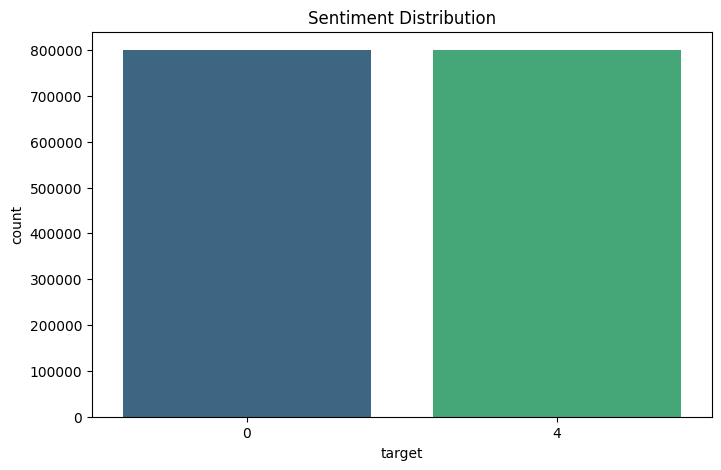

In [30]:
#exploring rating#
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='target',
    data=df,
    palette='viridis'
)

plt.title('Sentiment Distribution')

plt.show()

In [31]:
#Create Sentiment Function#
from textblob import TextBlob

def get_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"


In [35]:
# Take smaller sample
df = df.sample(5000)

# Apply sentiment
df['Sentiment'] = df['text'].apply(get_sentiment)

In [37]:
df[['text','Sentiment']].head(10)

,text,Sentiment
1051514,@JulieMa Except maybe Bend.,Neutral
441455,@lilysaid There was vengeance? And I missed it?,Neutral
1043844,@jun6lee uff tough q! I love every scene but e...,Positive
1397454,"@LedgeDancer Hey lady, thanks for noticing Y...",Negative
1166628,Can you top up my phone? Then may switch on. A...,Positive
207667,going out to family gathering! Oh what joy!,Positive
150077,Oooooooouuuuuuuuuuucccccccchhhhhhhhhh. In sooo...,Positive
563874,I has a sore tummy from eating a whole bag of ...,Positive
1348884,@TamekaRaymond Hi Tameka I been 2 busy 2 quote...,Positive
613197,@JDelgaado janet call me i need hepl with the ...,Neutral


In [38]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,2210
Neutral,1772
Negative,1018


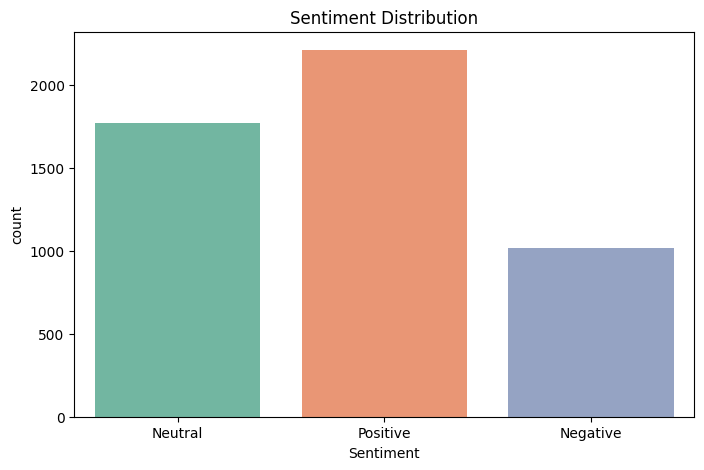

In [39]:
#Visualize Sentiment Distribution#
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df,
    palette='Set2'
)

plt.title('Sentiment Distribution')
plt.show()

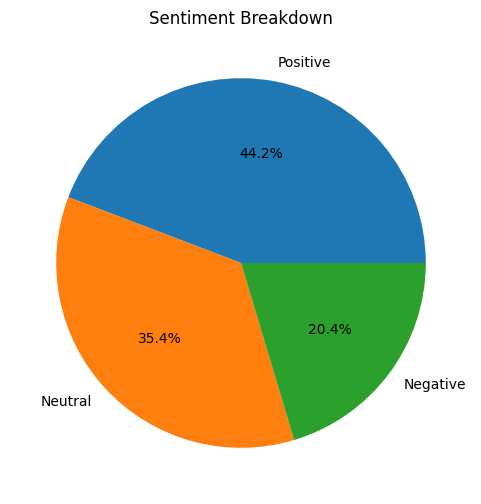

In [40]:
#Sentiment Percentage Pie Chart#
df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel('')
plt.title('Sentiment Breakdown')

plt.show()

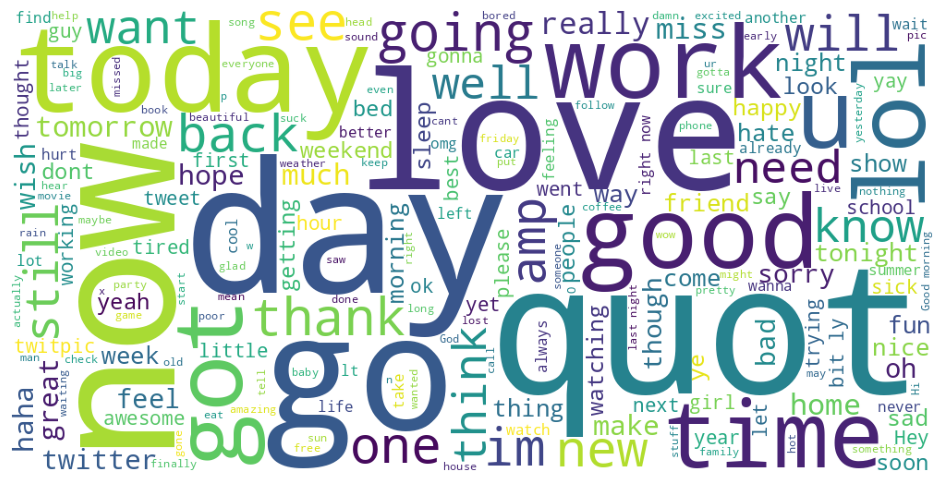

In [42]:
#Create Word Cloud#
from wordcloud import WordCloud

text = " ".join(df['text'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [44]:
#Analyze Review Lengths#
df['Review_Length'] = df['text'].astype(str).apply(len)

In [45]:
#Statistics#
df['Review_Length'].describe()

,Review_Length
count,5000.000000
mean,74.074800
std,36.144273
min,9.000000
25%,44.000000
50%,70.000000
75%,103.000000
max,181.000000


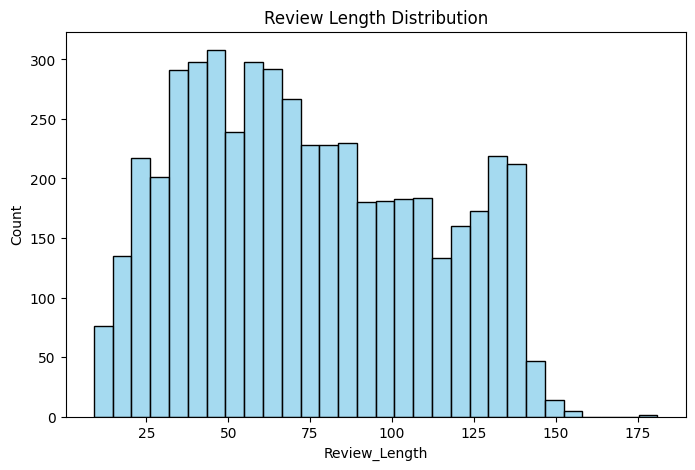

In [46]:
#Visualization#
plt.figure(figsize=(8,5))

sns.histplot(
    df['Review_Length'],
    bins=30,
    color='skyblue'
)

plt.title('Review Length Distribution')

plt.show()

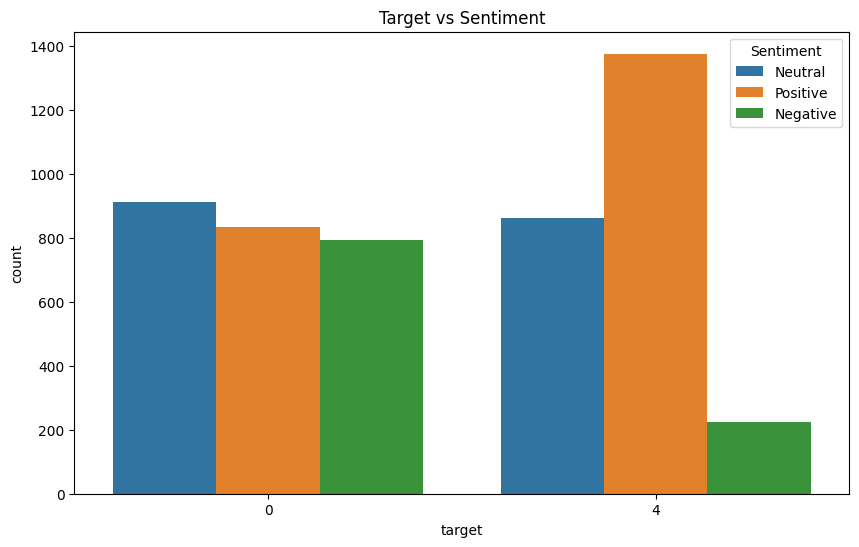

In [49]:
#Advanced Visualization#
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    x='target',
    hue='Sentiment',
    data=df
)

plt.title('Target vs Sentiment')

plt.show()

In [51]:
#Top Countries by Reviews#
df['target'].value_counts().head(10)

,count
target,
0,2540
4,2460


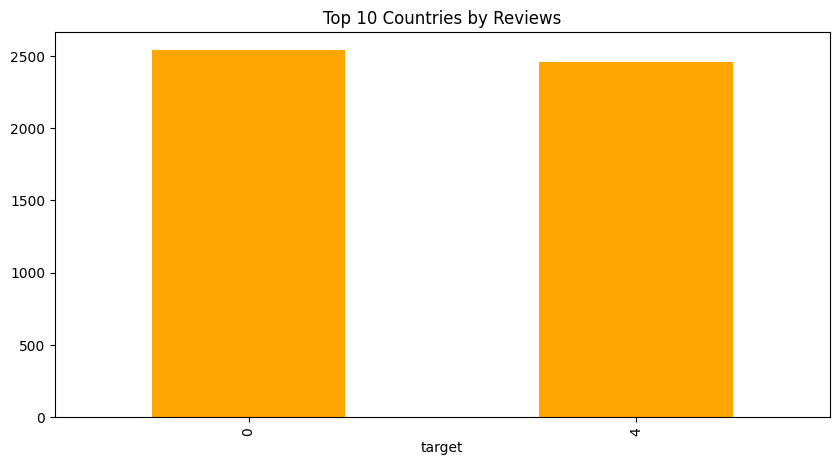

In [53]:
#Visualization#
plt.figure(figsize=(10,5))

df['target'].value_counts().head(10).plot(
    kind='bar',
    color='orange'
)

plt.title('Top 10 Countries by Reviews')

plt.show()

In [56]:
#creating lables from ratings#
def convert_sentiment(target):
    if target == 4:
        return "Positive"
    else:
        return "Negative"

df['Sentiment'] = df['target'].apply(convert_sentiment)

In [59]:
#prepare data for ml#
df = df[['text', 'Sentiment']]
df = df.dropna()

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(df['text'])
y = df['Sentiment']

In [62]:
#Train ML Model#
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [63]:
#Predictions#
y_pred = model.predict(X_test)

In [64]:
#Accuracy Score#
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.706


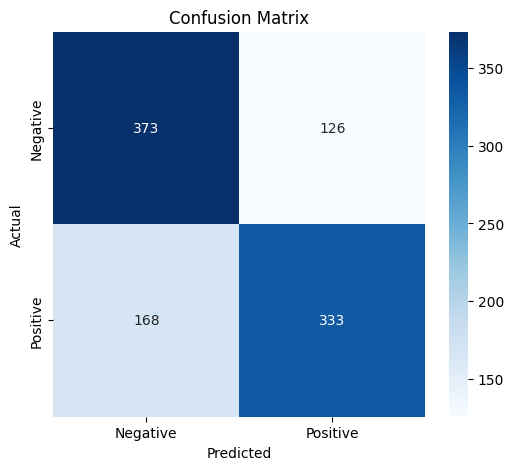

In [65]:
#Confusion Matrix#
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
#Real Prediction Function#
def predict_sentiment(text):
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    return prediction[0]

In [67]:
print(predict_sentiment("This app is amazing and very useful"))
print(predict_sentiment("Worst experience, very slow"))

Positive
Negative


In [69]:
print(df['Sentiment'].value_counts())

Sentiment
Negative    2540
Positive    2460
Name: count, dtype: int64


In [68]:
print("Conclusion:")
print("This project analyzes user sentiment on AI tool reviews using NLP techniques.")
print("Most users expressed positive sentiment, showing overall satisfaction.")
print("The analysis helps understand user perception using data-driven insights.")

Conclusion:
This project analyzes user sentiment on AI tool reviews using NLP techniques.
Most users expressed positive sentiment, showing overall satisfaction.
The analysis helps understand user perception using data-driven insights.
